# Stereo Scene Point Cloud

This notebook captures or loads a stereo scene pair, rectifies it with `calib/stereo_params_mono_first.pkl`, computes dense disparity, and exports a colored point cloud.

The main settings are camera indices, capture mode, histogram equalization, disparity range, and point-cloud depth filtering.




In [3]:
from __future__ import annotations

import pickle
import random
import struct
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

try:
    from pypylon import pylon
except Exception as exc:
    pylon = None
    print(f'pypylon unavailable: {exc}')

try:
    import open3d as o3d
except Exception as exc:
    o3d = None
    print(f'open3d unavailable; PLY export and matplotlib preview will still work: {exc}')


In [9]:
CALIB_ROOT = Path('calib')
STEREO_PARAMS_FILE = CALIB_ROOT / 'stereo_params_mono_first.pkl'
CAPTURE_DIR = Path('captures')
POINTCLOUD_DIR = Path('pointclouds')

LEFT_CAMERA_INDEX = 0
RIGHT_CAMERA_INDEX = 1
TAKE_NEW_CAPTURE = False  # Set False to reuse the latest *_L.png / *_R.png pair in CAPTURE_DIR.

# Leave as None to use the variant stored in the calibration file.
RIGHT_IMAGE_VARIANT_OVERRIDE = None

# Dense matching settings. Increase the disparity range for close objects.
SGBM_MIN_DISPARITY = 0
SGBM_NUM_DISPARITIES = 384  # Must be divisible by 16; increase for close objects with large disparity.
SGBM_AUTO_EXPAND_DISPARITY = True
SGBM_MAX_NUM_DISPARITIES = 512
SGBM_SATURATION_WARN_PERCENT = 5.0
SGBM_BLOCK_SIZE = 7        # Odd number, usually 5-11.
SGBM_UNIQUENESS_RATIO = 8
SGBM_SPECKLE_WINDOW_SIZE = 80
SGBM_SPECKLE_RANGE = 2

# Point-cloud filtering. Calibration units are millimeters.
POINT_MIN_DISPARITY = 1.0
POINT_MIN_DEPTH = 400.0
POINT_MAX_DEPTH = 650.0
MAX_POINTS_TO_SAVE = 400_000
RANDOM_SEED = 42

CAPTURE_DIR.mkdir(exist_ok=True)
POINTCLOUD_DIR.mkdir(exist_ok=True)


## Load Calibration

Load the stereo parameters saved by the calibration notebook.


In [10]:
def load_stereo_params(path: Path):
    if not path.exists():
        raise FileNotFoundError(f'Missing stereo params file: {path}')
    with path.open('rb') as f:
        params = pickle.load(f)

    required = ['mtxL', 'distL', 'mtxR', 'distR', 'R1', 'R2', 'P1', 'P2', 'Q']
    missing = [key for key in required if key not in params]
    if missing:
        raise KeyError(f'Stereo params file is missing keys: {missing}')

    print(f'Loaded {path}')
    for key in ['stereo_rms', 'rms', 'mono_rms_left', 'mono_rms_right', 'right_image_variant', 'swapped_intrinsics']:
        if key in params:
            print(f'{key}: {params[key]}')
    if 'T' in params:
        baseline = float(np.linalg.norm(np.asarray(params['T']).reshape(-1)))
        print(f'Baseline from T: {baseline:.3f} calibration units')
    return params


params = load_stereo_params(STEREO_PARAMS_FILE)


Loaded calib\stereo_params_mono_first.pkl
stereo_rms: 1.3366152860284264
mono_rms_left: 0.22752671790634602
mono_rms_right: 0.24089436362367125
right_image_variant: as_saved
swapped_intrinsics: True
Baseline from T: 123.288 calibration units


## Capture Or Load Scene Pair

The raw camera images are saved unchanged. Orientation handling for the right camera is applied during processing.


In [11]:
def require_pypylon():
    if pylon is None:
        raise RuntimeError('pypylon is not installed or the Basler SDK is missing')


def list_basler_devices():
    require_pypylon()
    tlf = pylon.TlFactory.GetInstance()
    devices = tlf.EnumerateDevices()
    for idx, device in enumerate(devices):
        print(idx, device.GetFriendlyName(), device.GetSerialNumber())
    return devices


def open_camera(index: int):
    require_pypylon()
    tlf = pylon.TlFactory.GetInstance()
    devices = tlf.EnumerateDevices()
    if index >= len(devices):
        raise RuntimeError(f'Camera index {index} not available; found {len(devices)} camera(s)')
    camera = pylon.InstantCamera(tlf.CreateDevice(devices[index]))
    camera.Open()
    return camera


def make_converter():
    require_pypylon()
    converter = pylon.ImageFormatConverter()
    converter.OutputPixelFormat = pylon.PixelType_BGR8packed
    converter.OutputBitAlignment = pylon.OutputBitAlignment_MsbAligned
    return converter


def capture_stereo_pair(left_index=LEFT_CAMERA_INDEX, right_index=RIGHT_CAMERA_INDEX, timeout_ms=5000):
    cam_left = open_camera(left_index)
    cam_right = open_camera(right_index)
    conv_left = make_converter()
    conv_right = make_converter()
    try:
        cam_left.StartGrabbingMax(1)
        cam_right.StartGrabbingMax(1)
        grab_left = cam_left.RetrieveResult(timeout_ms, pylon.TimeoutHandling_ThrowException)
        grab_right = cam_right.RetrieveResult(timeout_ms, pylon.TimeoutHandling_ThrowException)
        try:
            if not grab_left.GrabSucceeded() or not grab_right.GrabSucceeded():
                raise RuntimeError('At least one camera frame grab failed')
            frame_left = conv_left.Convert(grab_left).GetArray().copy()
            frame_right = conv_right.Convert(grab_right).GetArray().copy()
        finally:
            grab_left.Release()
            grab_right.Release()
    finally:
        cam_left.Close()
        cam_right.Close()
    return frame_left, frame_right


def save_scene_stereo_pair():
    frame_left, frame_right = capture_stereo_pair()
    ts = time.strftime('%Y%m%d_%H%M%S')
    left_path = CAPTURE_DIR / f'stereo_scene_{ts}_L.png'
    right_path = CAPTURE_DIR / f'stereo_scene_{ts}_R.png'
    cv2.imwrite(str(left_path), frame_left)
    cv2.imwrite(str(right_path), frame_right)
    print(f'Saved {left_path}')
    print(f'Saved {right_path}')
    return left_path, right_path


def latest_stereo_pair(directory: Path):
    left_paths = sorted(directory.glob('*_L.png'))
    candidates = []
    for left_path in left_paths:
        right_path = left_path.with_name(left_path.name[:-6] + '_R.png')
        if right_path.exists():
            candidates.append((left_path, right_path))
    if not candidates:
        raise FileNotFoundError(f'No stereo pairs found in {directory}; expected filenames ending in _L.png and _R.png')
    return candidates[-1]


In [12]:
# Check camera order before capturing.
if pylon is not None:
    print('Connected Basler devices:')
    list_basler_devices()

if TAKE_NEW_CAPTURE:
    scene_left_path, scene_right_path = save_scene_stereo_pair()
else:
    scene_left_path, scene_right_path = latest_stereo_pair(CAPTURE_DIR)
    print(f'Reusing latest pair:\n  {scene_left_path}\n  {scene_right_path}')


Connected Basler devices:
Reusing latest pair:
  captures\stereo_scene_20260615_170755_L.png
  captures\stereo_scene_20260615_170755_R.png


## Histogram Equalization

This contrast step can make dense matching more stable. The raw images remain available for comparison; the processed images are used for rectification and disparity.


In [13]:
APPLY_HISTOGRAM_EQUALIZATION = True
HISTOGRAM_EQUALIZATION_METHOD = 'clahe'  # 'clahe', 'global', or 'none'
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)


def load_bgr(path: Path):
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(f'Could not read image: {path}')
    return image


def equalize_histogram_bgr(image, method='clahe', clip_limit=2.0, tile_grid_size=(8, 8)):
    if method in (None, 'none'):
        return image.copy()

    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    if method == 'global':
        l_equalized = cv2.equalizeHist(l_channel)
    elif method == 'clahe':
        clahe = cv2.createCLAHE(clipLimit=float(clip_limit), tileGridSize=tuple(tile_grid_size))
        l_equalized = clahe.apply(l_channel)
    else:
        raise ValueError(f'Unknown histogram equalization method: {method}')

    equalized_lab = cv2.merge([l_equalized, a_channel, b_channel])
    return cv2.cvtColor(equalized_lab, cv2.COLOR_LAB2BGR)


def preprocess_scene_images(left_bgr, right_bgr):
    if not APPLY_HISTOGRAM_EQUALIZATION:
        print('Histogram equalization disabled')
        return left_bgr.copy(), right_bgr.copy()
    left_processed = equalize_histogram_bgr(
        left_bgr,
        method=HISTOGRAM_EQUALIZATION_METHOD,
        clip_limit=CLAHE_CLIP_LIMIT,
        tile_grid_size=CLAHE_TILE_GRID_SIZE,
    )
    right_processed = equalize_histogram_bgr(
        right_bgr,
        method=HISTOGRAM_EQUALIZATION_METHOD,
        clip_limit=CLAHE_CLIP_LIMIT,
        tile_grid_size=CLAHE_TILE_GRID_SIZE,
    )
    print(f'Applied {HISTOGRAM_EQUALIZATION_METHOD} histogram equalization')
    return left_processed, right_processed


raw_left = load_bgr(scene_left_path)
raw_right = load_bgr(scene_right_path)
scene_left_for_processing, scene_right_for_processing = preprocess_scene_images(raw_left, raw_right)


Applied clahe histogram equalization


## Rectify The Pair

After rectification, corresponding image points should lie on the same horizontal row.


In [14]:
def apply_right_variant(image, variant: str):
    if variant in (None, 'as_saved'):
        return image
    if variant == 'flip_horizontal':
        return cv2.flip(image, 1)
    if variant == 'flip_vertical':
        return cv2.flip(image, 0)
    if variant == 'rot180':
        return cv2.rotate(image, cv2.ROTATE_180)
    raise ValueError(f'Unknown right image variant: {variant}')


def calibration_image_size(params, fallback_shape):
    if 'image_size' in params:
        size = tuple(int(v) for v in params['image_size'])
        if len(size) == 2:
            return size
    h, w = fallback_shape[:2]
    return (w, h)


def rectify_scene_pair(left_bgr, right_bgr_raw, params):
    right_variant = RIGHT_IMAGE_VARIANT_OVERRIDE
    if right_variant is None:
        right_variant = params.get('right_image_variant', 'as_saved')
    right_bgr = apply_right_variant(right_bgr_raw, right_variant)

    image_size = calibration_image_size(params, left_bgr.shape)
    current_size = (left_bgr.shape[1], left_bgr.shape[0])
    if current_size != image_size:
        raise ValueError(f'Capture size {current_size} does not match calibration image_size {image_size}')
    if (right_bgr.shape[1], right_bgr.shape[0]) != image_size:
        raise ValueError(f'Right image size {(right_bgr.shape[1], right_bgr.shape[0])} does not match calibration image_size {image_size}')

    map_lx, map_ly = cv2.initUndistortRectifyMap(params['mtxL'], params['distL'], params['R1'], params['P1'], image_size, cv2.CV_32FC1)
    map_rx, map_ry = cv2.initUndistortRectifyMap(params['mtxR'], params['distR'], params['R2'], params['P2'], image_size, cv2.CV_32FC1)
    rect_left = cv2.remap(left_bgr, map_lx, map_ly, cv2.INTER_LINEAR)
    rect_right = cv2.remap(right_bgr, map_rx, map_ry, cv2.INTER_LINEAR)
    print(f'Right image variant used: {right_variant}')
    return rect_left, rect_right, right_bgr


rect_left, rect_right, processed_right = rectify_scene_pair(scene_left_for_processing, scene_right_for_processing, params)
print(f'Raw shape: {raw_left.shape}; processed shape: {scene_left_for_processing.shape}; rectified shape: {rect_left.shape}')


Right image variant used: as_saved
Raw shape: (1024, 1280, 3); processed shape: (1024, 1280, 3); rectified shape: (1024, 1280, 3)


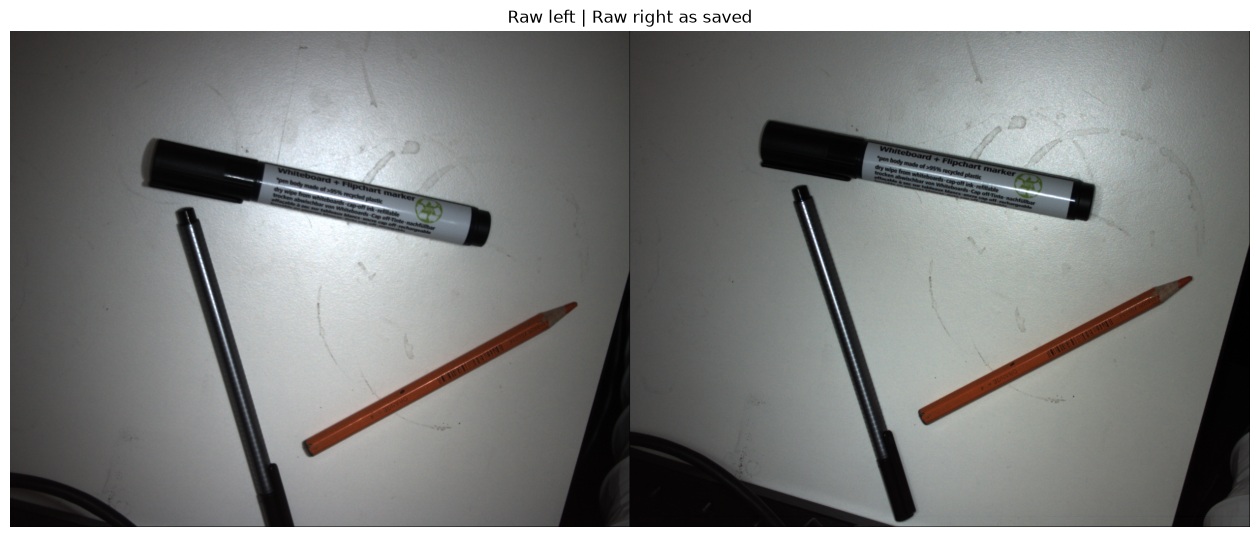

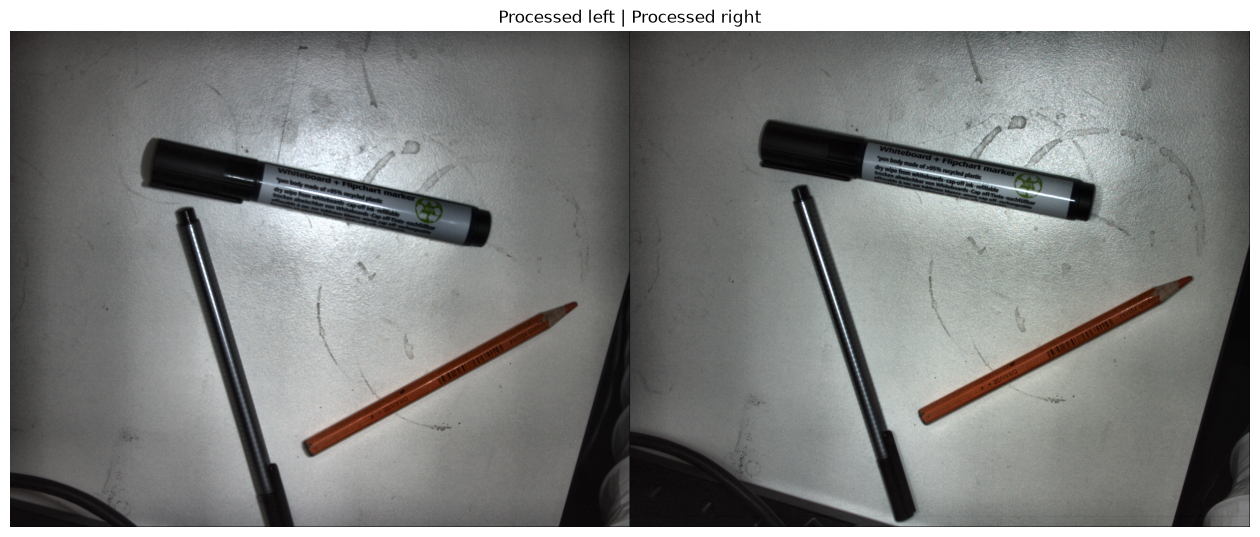

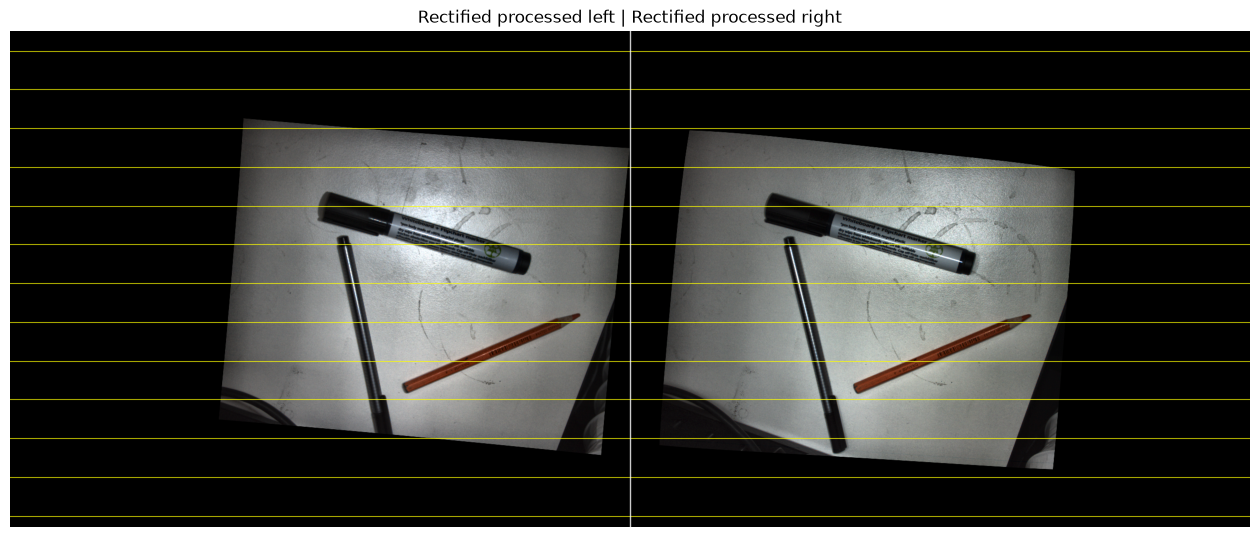

In [15]:
def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
   

def show_side_by_side(left, right, title_left='Left', title_right='Right', lines=False, step=80):
    left_bgr = bgr_to_rgb(left)
    right_bgr = bgr_to_rgb(right)
    combined = np.hstack([left_bgr, right_bgr])
    fig, ax = plt.subplots(figsize=(16, 7))
    ax.imshow(combined)
    ax.set_title(f'{title_left} | {title_right}')
    ax.axis('off')
    if lines:
        h, w = left.shape[:2]
        for y in range(step // 2, h, step):
            ax.axhline(y, color='yellow', linewidth=0.8, alpha=0.65)
        ax.axvline(w, color='white', linewidth=1.0, alpha=0.8)
    plt.show()


show_side_by_side(raw_left, raw_right, 'Raw left', 'Raw right as saved', lines=False)
show_side_by_side(scene_left_for_processing, scene_right_for_processing, 'Processed left', 'Processed right', lines=False)
show_side_by_side(rect_left, rect_right, 'Rectified processed left', 'Rectified processed right', lines=True)


## Object Detection With YOLO


Left raw image: 3 object(s) detected
  Pencil: conf=0.81, bbox=(611, 582)-(1148, 875)
  Fineliner: conf=0.53, bbox=(348, 372)-(587, 1024)
  Marker: conf=0.48, bbox=(289, 265)-(988, 454)
Right raw image: 3 object(s) detected
  Pencil: conf=0.82, bbox=(603, 518)-(1141, 811)
  Fineliner: conf=0.57, bbox=(333, 314)-(560, 962)
  Marker: conf=0.55, bbox=(270, 198)-(936, 396)


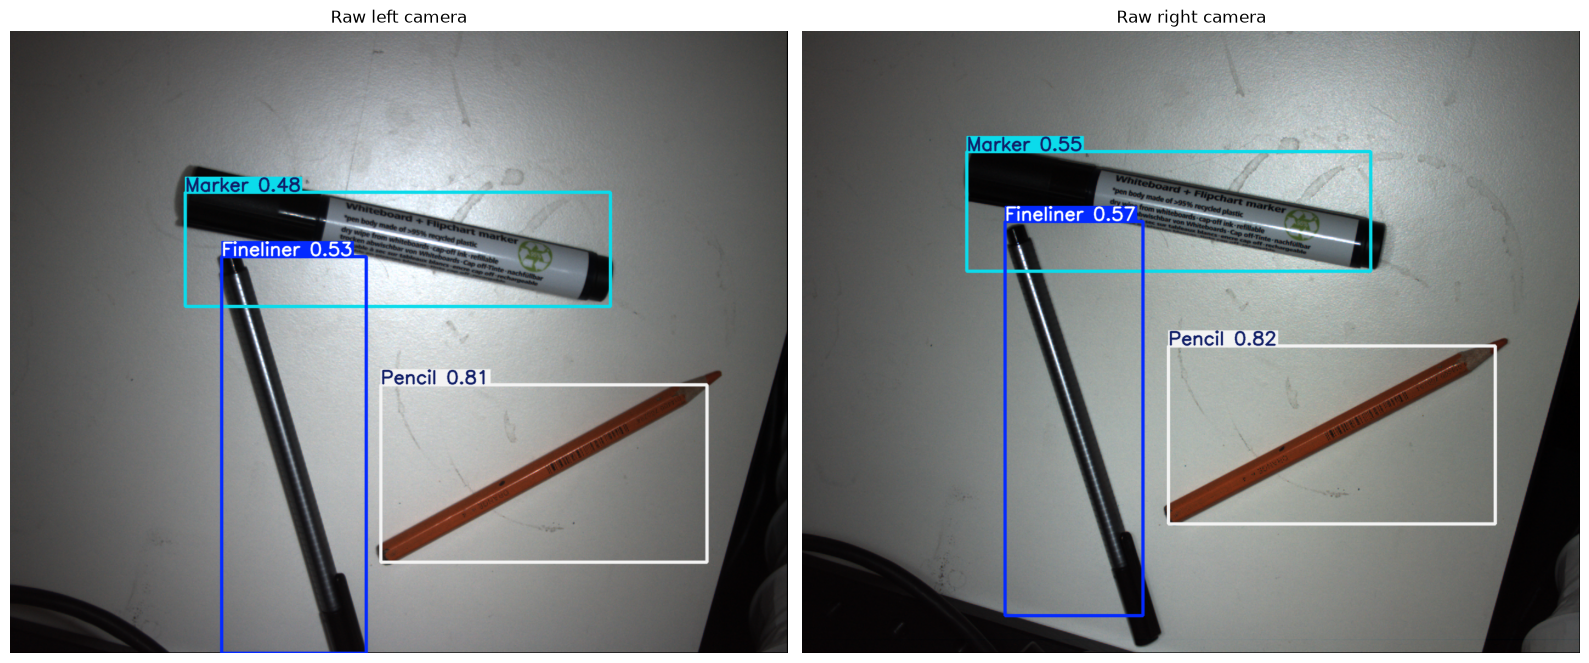

Saved detections\yolo_scene_20260618_100035_L.png
Saved detections\yolo_scene_20260618_100035_R.png


In [16]:
YOLO_MODEL_SOURCE = 'best.pt'  # Use a local .pt path to avoid downloading weights.
YOLO_CONFIDENCE = 0.4 # Set higher confidence threshold to reduce false positives in the complex scene;
YOLO_IOU = 0.45 
YOLO_CLASSES = None  # Example: [0] for COCO person only; leave None for all classes.
YOLO_OUTPUT_DIR = Path('detections')
YOLO_OUTPUT_DIR.mkdir(exist_ok=True)


def require_yolo():
    try:
        from ultralytics import YOLO
    except ImportError as exc:
        raise RuntimeError('Install project dependencies with: pdm install') from exc
    return YOLO


def run_yolo_on_raw_scene(left_bgr, right_bgr, model_source=YOLO_MODEL_SOURCE):
    YOLO = require_yolo()
    model = YOLO(model_source)
    results = model.predict(
        source=[left_bgr, right_bgr],
        conf=float(YOLO_CONFIDENCE),
        iou=float(YOLO_IOU),
        classes=YOLO_CLASSES,
        verbose=False,
    )
    return results


def summarize_yolo_result(result, camera_label):
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        print(f'{camera_label}: no objects detected')
        return

    print(f'{camera_label}: {len(boxes)} object(s) detected')
    for box in boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        label = result.names.get(class_id, str(class_id))
        x1, y1, x2, y2 = [float(v) for v in box.xyxy[0]]
        print(f'  {label}: conf={confidence:.2f}, bbox=({x1:.0f}, {y1:.0f})-({x2:.0f}, {y2:.0f})')


def show_yolo_raw_detections(results):
    labels = ['Raw left camera', 'Raw right camera']
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for ax, result, label in zip(axes, results, labels):
        annotated_bgr = result.plot()
        ax.imshow(cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(label)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def save_yolo_annotations(results):
    ts = time.strftime('%Y%m%d_%H%M%S')
    saved_paths = []
    for result, suffix in zip(results, ['L', 'R']):
        annotated_bgr = result.plot()
        out_path = YOLO_OUTPUT_DIR / f'yolo_scene_{ts}_{suffix}.png'
        cv2.imwrite(str(out_path), annotated_bgr)
        saved_paths.append(out_path)
        print(f'Saved {out_path}')
    return saved_paths


yolo_results = run_yolo_on_raw_scene(raw_left, raw_right)
for result, label in zip(yolo_results, ['Left raw image', 'Right raw image']):
    summarize_yolo_result(result, label)
show_yolo_raw_detections(yolo_results)
yolo_annotation_paths = save_yolo_annotations(yolo_results)


## Dense Matching And Disparity

StereoSGBM estimates the horizontal pixel shift between the rectified images. The valid mask shows where a correspondence was accepted.


In [17]:
def make_odd(value: int):
    value = int(value)
    return value if value % 2 else value + 1


def make_num_disparities(value: int):
    value = max(16, int(value))
    return int(np.ceil(value / 16.0) * 16)


def enhance_for_matching(gray):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)


def _compute_disparity_once(left_bgr, right_bgr, num_disparities):
    gray_left = cv2.cvtColor(left_bgr, cv2.COLOR_BGR2GRAY)
    gray_right = cv2.cvtColor(right_bgr, cv2.COLOR_BGR2GRAY)
    gray_left = enhance_for_matching(gray_left)
    gray_right = enhance_for_matching(gray_right)

    block_size = make_odd(SGBM_BLOCK_SIZE)
    num_disparities = make_num_disparities(num_disparities)
    matcher = cv2.StereoSGBM_create(
        minDisparity=int(SGBM_MIN_DISPARITY),
        numDisparities=num_disparities,
        blockSize=block_size,
        P1=8 * 3 * block_size ** 2,
        P2=32 * 3 * block_size ** 2,
        disp12MaxDiff=1,
        uniquenessRatio=int(SGBM_UNIQUENESS_RATIO),
        speckleWindowSize=int(SGBM_SPECKLE_WINDOW_SIZE),
        speckleRange=int(SGBM_SPECKLE_RANGE),
        preFilterCap=63,
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY,
    )
    disparity = matcher.compute(gray_left, gray_right).astype(np.float32) / 16.0
    return disparity, block_size, num_disparities


def disparity_stats(disparity):
    max_valid_disparity = SGBM_MIN_DISPARITY + make_num_disparities(current_num_disparities) - 1
    valid = np.isfinite(disparity) & (disparity > (SGBM_MIN_DISPARITY + POINT_MIN_DISPARITY))
    if not valid.any():
        return valid, 0.0, 0.0, np.nan
    near_upper = disparity >= (max_valid_disparity - 1.0)
    saturated_pct = 100.0 * (near_upper & valid).sum() / valid.sum()
    valid_pct = 100.0 * valid.mean()
    median_disp = float(np.median(disparity[valid]))
    return valid, valid_pct, saturated_pct, median_disp


def compute_disparity(left_bgr, right_bgr):
    global current_num_disparities
    current_num_disparities = make_num_disparities(SGBM_NUM_DISPARITIES)

    while True:
        disparity, block_size, used_num_disparities = _compute_disparity_once(left_bgr, right_bgr, current_num_disparities)
        valid, valid_pct, saturated_pct, median_disp = disparity_stats(disparity)
        max_valid_disparity = SGBM_MIN_DISPARITY + used_num_disparities - 1

        print(f'SGBM block_size={block_size}, num_disparities={used_num_disparities}, min_disparity={SGBM_MIN_DISPARITY}')
        print(f'  Disparity range: {float(np.nanmin(disparity)):.2f} to {float(np.nanmax(disparity)):.2f} px')
        print(f'  Valid matching pixels: {valid.sum():,} / {valid.size:,} ({valid_pct:.2f}%)')
        if valid.any():
            print(f'  Median valid disparity: {median_disp:.2f} px')
            print(f'  Pixels at upper disparity limit ({max_valid_disparity - 1:.0f}..{max_valid_disparity:.0f}px): {saturated_pct:.2f}% of valid pixels')

        can_expand = current_num_disparities < make_num_disparities(SGBM_MAX_NUM_DISPARITIES)
        is_saturated = valid.any() and saturated_pct > SGBM_SATURATION_WARN_PERCENT
        if SGBM_AUTO_EXPAND_DISPARITY and is_saturated and can_expand:
            next_num = min(current_num_disparities * 2, make_num_disparities(SGBM_MAX_NUM_DISPARITIES))
            if next_num == current_num_disparities:
                break
            print(f'  Disparity is saturating; retrying with num_disparities={next_num}.')
            current_num_disparities = next_num
            continue

        if is_saturated:
            print('WARNING: disparity is still saturating at the upper limit. Increase SGBM_MAX_NUM_DISPARITIES or move the object farther away.')
        return disparity

disparity = compute_disparity(rect_left, rect_right)
valid_disparity_mask, valid_pct, saturated_pct, median_disp = disparity_stats(disparity)


SGBM block_size=7, num_disparities=384, min_disparity=0
  Disparity range: -1.00 to 383.00 px
  Valid matching pixels: 450,416 / 1,310,720 (34.36%)
  Median valid disparity: 357.81 px
  Pixels at upper disparity limit (382..383px): 8.91% of valid pixels
  Disparity is saturating; retrying with num_disparities=512.
SGBM block_size=7, num_disparities=512, min_disparity=0
  Disparity range: -1.00 to 511.00 px
  Valid matching pixels: 343,468 / 1,310,720 (26.20%)
  Median valid disparity: 353.75 px
  Pixels at upper disparity limit (510..511px): 6.80% of valid pixels


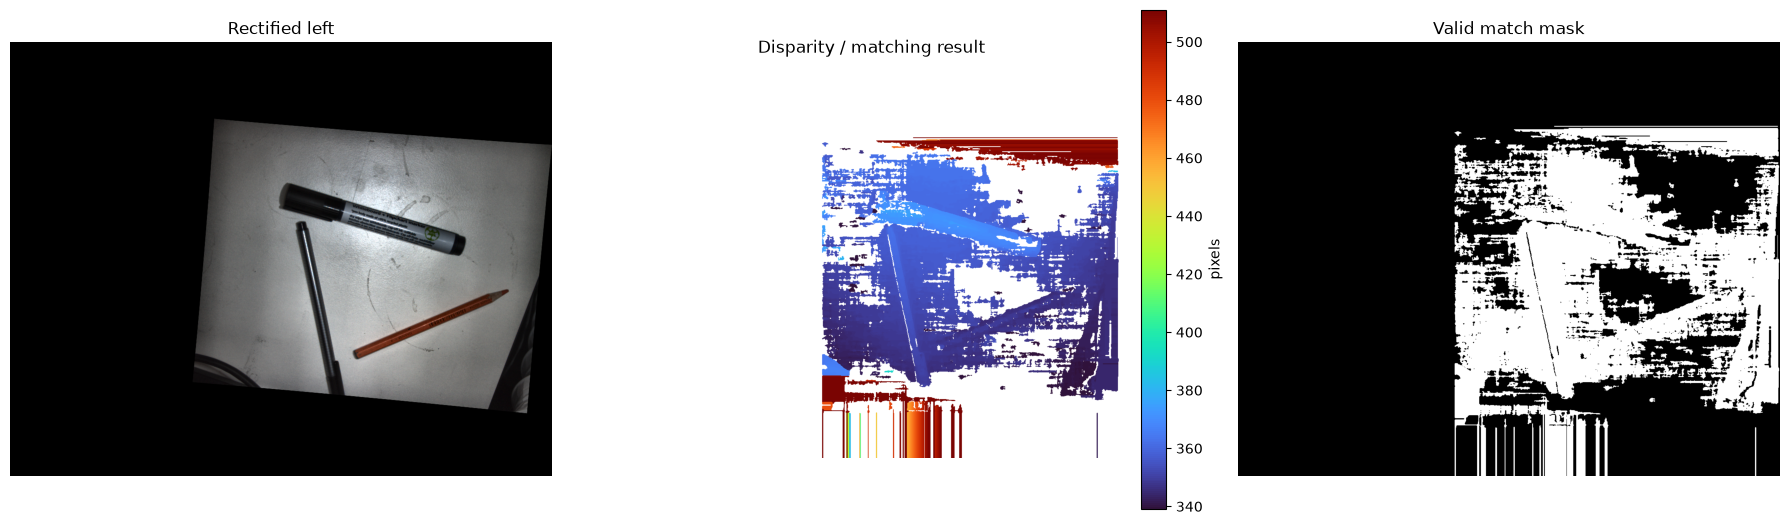

In [18]:
def show_disparity_and_mask(disparity, mask):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(bgr_to_rgb(rect_left))
    axes[0].set_title('Rectified left')
    axes[0].axis('off')

    disp_vis = np.ma.masked_where(~mask, disparity)
    if mask.any():
        vmin, vmax = np.percentile(disparity[mask], [2, 98])
    else:
        vmin, vmax = 0, 1
    im = axes[1].imshow(disp_vis, cmap='turbo', vmin=vmin, vmax=vmax)
    axes[1].set_title('Disparity / matching result')
    axes[1].axis('off')
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label='pixels')

    axes[2].imshow(mask, cmap='gray')
    axes[2].set_title('Valid match mask')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()


show_disparity_and_mask(disparity, valid_disparity_mask)


## Point Cloud Export

The `Q` matrix converts valid disparity pixels into 3D coordinates. Colors are sampled from the rectified left image.


In [19]:
def reproject_to_pointcloud(disparity, rect_left_bgr, params):
    points_3d = cv2.reprojectImageTo3D(disparity, params['Q'])
    colors_rgb = cv2.cvtColor(rect_left_bgr, cv2.COLOR_BGR2RGB)

    finite = np.isfinite(points_3d).all(axis=2)
    positive_disp = disparity > (SGBM_MIN_DISPARITY + POINT_MIN_DISPARITY)
    rough_mask = finite & positive_disp

    if not rough_mask.any():
        raise RuntimeError('No valid disparity pixels. Try increasing texture/light, reducing uniqueness ratio, or changing num_disparities.')

    z = points_3d[:, :, 2]
    median_z = float(np.median(z[rough_mask]))
    z_sign = 1.0 if median_z >= 0 else -1.0
    depth = z * z_sign
    mask = rough_mask & (depth >= POINT_MIN_DEPTH) & (depth <= POINT_MAX_DEPTH)

    if not mask.any():
        raise RuntimeError('All points were filtered by depth. Loosen POINT_MIN_DEPTH / POINT_MAX_DEPTH.')

    points = points_3d[mask].astype(np.float32)
    if z_sign < 0:
        points *= -1.0
        print('Point cloud sign was flipped so forward depth is positive.')
    colors = colors_rgb[mask].astype(np.uint8)

    print(f'Point cloud pixels after filtering: {len(points):,}')
    print(f'X range: {points[:, 0].min():.1f} to {points[:, 0].max():.1f}')
    print(f'Y range: {points[:, 1].min():.1f} to {points[:, 1].max():.1f}')
    print(f'Z range: {points[:, 2].min():.1f} to {points[:, 2].max():.1f}')
    print(f'Median Z: {np.median(points[:, 2]):.1f}')
    return points, colors, mask


def subsample_points(points, colors, max_points=MAX_POINTS_TO_SAVE):
    if len(points) <= max_points:
        return points, colors
    rng = np.random.default_rng(RANDOM_SEED)
    idx = rng.choice(len(points), size=max_points, replace=False)
    return points[idx], colors[idx]


def save_pointcloud_ply(path: Path, points, colors):
    path = Path(path)
    path.parent.mkdir(exist_ok=True)
    with path.open('wb') as f:
        f.write(b'ply\n')
        f.write(b'format binary_little_endian 1.0\n')
        f.write(f'element vertex {len(points)}\n'.encode('ascii'))
        f.write(b'property float x\n')
        f.write(b'property float y\n')
        f.write(b'property float z\n')
        f.write(b'property uchar red\n')
        f.write(b'property uchar green\n')
        f.write(b'property uchar blue\n')
        f.write(b'end_header\n')
        for point, color in zip(points, colors):
            f.write(struct.pack('<fffBBB', float(point[0]), float(point[1]), float(point[2]), int(color[0]), int(color[1]), int(color[2])))
    print(f'Saved {path} ({path.stat().st_size / 1024 / 1024:.2f} MB)')


points, colors, point_mask = reproject_to_pointcloud(disparity, rect_left, params)
points_to_save, colors_to_save = subsample_points(points, colors)
ply_path = POINTCLOUD_DIR / f'scene_pointcloud_{time.strftime("%Y%m%d_%H%M%S")}.ply'
save_pointcloud_ply(ply_path, points_to_save, colors_to_save)


Point cloud pixels after filtering: 295,604
X range: -77.1 to 200.4
Y range: -146.1 to 154.6
Z range: 400.3 to 649.9
Median Z: 561.1
Saved pointclouds\scene_pointcloud_20260618_100054.ply (4.23 MB)


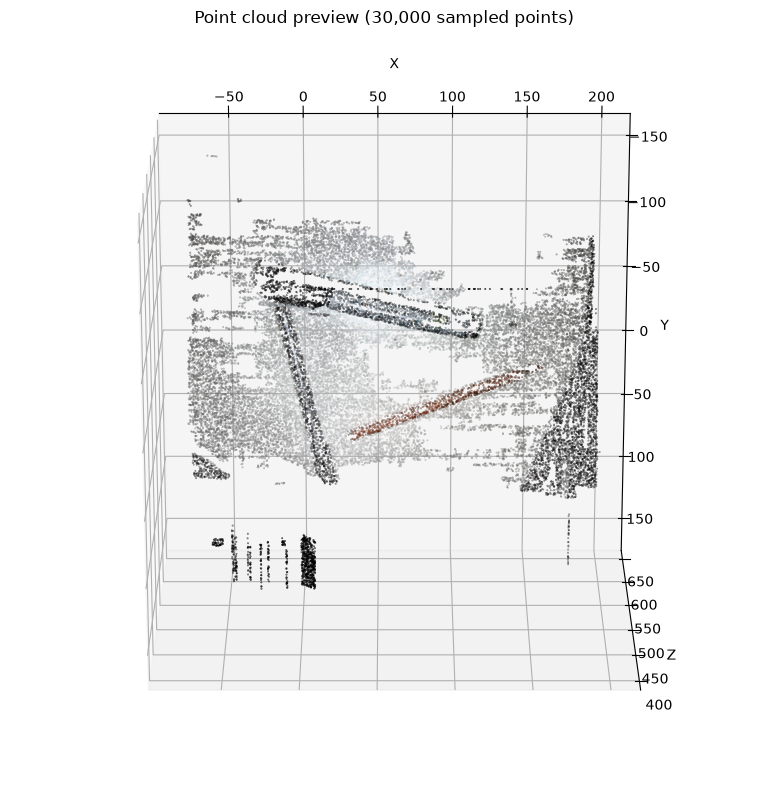

In [20]:
def preview_pointcloud(points, colors, max_preview_points=30_000):
    if len(points) == 0:
        raise RuntimeError('No points to preview')
    rng = np.random.default_rng(RANDOM_SEED)
    if len(points) > max_preview_points:
        idx = rng.choice(len(points), size=max_preview_points, replace=False)
        pts = points[idx]
        cols = colors[idx].astype(np.float32) / 255.0
    else:
        pts = points
        cols = colors.astype(np.float32) / 255.0

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=cols, s=0.5, marker='.')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Point cloud preview ({len(pts):,} sampled points)')
    ax.view_init(elev=-70, azim=-90)
    plt.tight_layout()
    plt.show()


preview_pointcloud(points, colors)


In [33]:
# Open3D viewer, when available in the active kernel.
if o3d is None:
    print('Open3D is not available in this kernel. Use the PLY file in MeshLab, CloudCompare, or another viewer.')
else:
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points_to_save)
    pcd.colors = o3d.utility.Vector3dVector(colors_to_save.astype(np.float64) / 255.0)
    o3d.visualization.draw_geometries([pcd])


## Data sanitation


Disparity minimum threshold: removed 8,803 valid pixels below 340.0px.
Disparity maximum threshold: removed 55,855 valid pixels above 390.0px.
Disparity X/Y crop: x=0:1280, y=0:1024; removed 0 valid pixels outside crop.
Disparity first pass: removed 64,658 valid pixels total (18.83%).


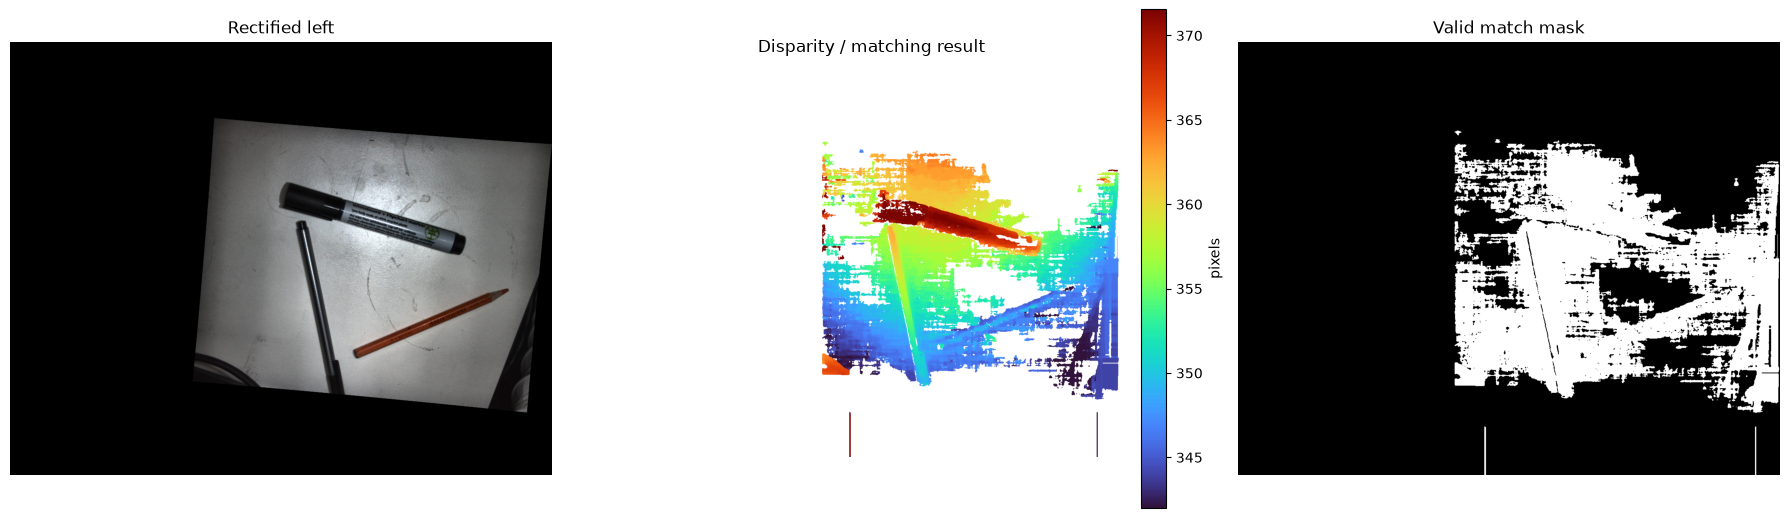

In [21]:
# First sanitation pass: invalidate impossible disparity values and border/stripe artifacts in image space.
DISPARITY_MIN_THRESHOLD = 340  # pixels; set a number to cut far/low-disparity artifacts
DISPARITY_MAX_THRESHOLD = 390.0
DISPARITY_INVALID_VALUE = SGBM_MIN_DISPARITY - 1.0

# Pixel-space crop in the disparity image. Use None to keep that side unchanged.
# Example: DISPARITY_KEEP_X_RANGE = (80, 1210) keeps columns 80..1209.
DISPARITY_KEEP_X_RANGE = (None, None)
DISPARITY_KEEP_Y_RANGE = (None, None)


def _resolve_pixel_range(pixel_range, size, axis_name):
    start, stop = pixel_range
    start = 0 if start is None else int(start)
    stop = size if stop is None else int(stop)
    start = max(0, min(start, size))
    stop = max(start, min(stop, size))
    if start >= stop:
        raise ValueError(f'{axis_name} crop leaves no pixels: {pixel_range} for size {size}')
    return start, stop


def cut_disparity(disparity, min_disparity=DISPARITY_MIN_THRESHOLD, max_disparity=DISPARITY_MAX_THRESHOLD, x_range=DISPARITY_KEEP_X_RANGE, y_range=DISPARITY_KEEP_Y_RANGE):
    thresholded = disparity.copy()
    height, width = thresholded.shape[:2]
    x_start, x_stop = _resolve_pixel_range(x_range, width, 'X')
    y_start, y_stop = _resolve_pixel_range(y_range, height, 'Y')

    finite = np.isfinite(thresholded)
    below_threshold = np.zeros_like(thresholded, dtype=bool)
    if min_disparity is not None:
        below_threshold = finite & (thresholded < float(min_disparity))
    above_threshold = finite & (thresholded > float(max_disparity))

    inside_xy = np.zeros_like(thresholded, dtype=bool)
    inside_xy[y_start:y_stop, x_start:x_stop] = True
    outside_xy = ~inside_xy

    cut_mask = below_threshold | above_threshold | outside_xy
    thresholded[cut_mask] = DISPARITY_INVALID_VALUE

    valid_before = finite & (disparity > (SGBM_MIN_DISPARITY + POINT_MIN_DISPARITY))
    valid_after = np.isfinite(thresholded) & (thresholded > (SGBM_MIN_DISPARITY + POINT_MIN_DISPARITY))
    removed = int(valid_before.sum() - valid_after.sum())
    removed_pct = 100.0 * removed / valid_before.sum() if valid_before.any() else 0.0

    if min_disparity is not None:
        print(f'Disparity minimum threshold: removed {int((below_threshold & valid_before).sum()):,} valid pixels below {float(min_disparity):.1f}px.')
    else:
        print('Disparity minimum threshold: disabled.')
    print(f'Disparity maximum threshold: removed {int((above_threshold & valid_before).sum()):,} valid pixels above {float(max_disparity):.1f}px.')
    print(f'Disparity X/Y crop: x={x_start}:{x_stop}, y={y_start}:{y_stop}; removed {int((outside_xy & valid_before).sum()):,} valid pixels outside crop.')
    print(f'Disparity first pass: removed {removed:,} valid pixels total ({removed_pct:.2f}%).')
    return thresholded, cut_mask, below_threshold, above_threshold, outside_xy


disparity_thresholded, disparity_first_pass_cut_mask, disparity_under_threshold_mask, disparity_over_threshold_mask, disparity_outside_xy_mask = cut_disparity(disparity)
valid_disparity_thresholded_mask, valid_thresholded_pct, saturated_thresholded_pct, median_thresholded_disp = disparity_stats(disparity_thresholded)
show_disparity_and_mask(disparity_thresholded, valid_disparity_thresholded_mask)


In [22]:
# Export the point cloud after only the disparity threshold/X-Y crop pass.
thresholded_points, thresholded_colors, thresholded_point_mask = reproject_to_pointcloud(disparity_thresholded, rect_left, params)
thresholded_points_to_save, thresholded_colors_to_save = subsample_points(
    thresholded_points,
    thresholded_colors,
    max_points=MAX_POINTS_TO_SAVE,
)
thresholded_ply_path = POINTCLOUD_DIR / f'scene_pointcloud_disparity_cut_{time.strftime("%Y%m%d_%H%M%S")}.ply'
save_pointcloud_ply(thresholded_ply_path, thresholded_points_to_save, thresholded_colors_to_save)


Point cloud pixels after filtering: 278,810
X range: -77.1 to 197.3
Y range: -133.0 to 154.6
Z range: 515.3 to 580.7
Median Z: 561.2
Saved pointclouds\scene_pointcloud_disparity_cut_20260618_100107.ply (3.99 MB)


Sanitation kept 268,574 / 278,810 candidate points (96.33%).
Removed by depth/disparity/bounds: 0
Removed as detached components: 10,236
Removed total: 10,236 (3.67%).
Removed connected components: 38; largest removed areas: [1932, 1264, 1144, 1097, 631]
X range: -77.1 to 197.3
Y range: -122.6 to 100.3
Z range: 523.9 to 580.7
Saved pointclouds\scene_pointcloud_sanitized_20260618_100109.ply (3.84 MB)


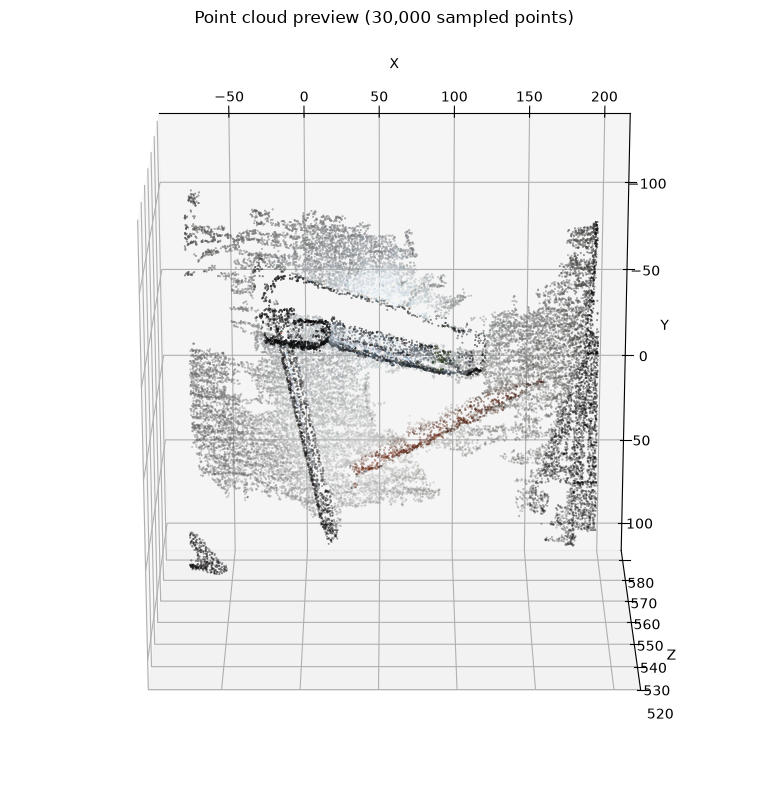

In [23]:
# Cut detached/out-of-scope geometry after disparity reprojection.
# The default cleanup keeps the main connected disparity region and removes small detached islands.
SANITIZE_MIN_DEPTH = POINT_MIN_DEPTH
SANITIZE_MAX_DEPTH = POINT_MAX_DEPTH
SANITIZE_MAX_ABS_X = None      # millimeters; set a number to enable X clipping
SANITIZE_MAX_ABS_Y = None      # millimeters; set a number to enable Y clipping
SANITIZE_MIN_DISPARITY = POINT_MIN_DISPARITY
SANITIZE_MAX_DISPARITY = None  # pixels; set a number to clip very near saturated matches
SANITIZE_KEEP_LARGEST_COMPONENTS = 1
SANITIZE_MIN_COMPONENT_AREA = 2000
SANITIZE_COMPONENT_CONNECTIVITY = 8
SANITIZED_MAX_POINTS_TO_SAVE = MAX_POINTS_TO_SAVE


def keep_connected_components(mask, keep_largest=1, min_area=2_000, connectivity=8):
    mask_u8 = mask.astype(np.uint8)
    component_count, labels, stats, _ = cv2.connectedComponentsWithStats(mask_u8, connectivity=connectivity)
    if component_count <= 1:
        return mask.copy(), []

    components = []
    for label in range(1, component_count):
        area = int(stats[label, cv2.CC_STAT_AREA])
        components.append((label, area))
    components.sort(key=lambda item: item[1], reverse=True)

    keep_labels = {label for label, _ in components[:int(keep_largest)]}
    keep_labels.update(label for label, area in components if area >= int(min_area))

    connected_mask = np.isin(labels, list(keep_labels))
    removed_components = [(label, area) for label, area in components if label not in keep_labels]
    return connected_mask, removed_components


def sanitize_pointcloud_from_disparity(disparity, rect_left_bgr, params):
    points_3d = cv2.reprojectImageTo3D(disparity, params['Q'])
    colors_rgb = cv2.cvtColor(rect_left_bgr, cv2.COLOR_BGR2RGB)

    finite = np.isfinite(points_3d).all(axis=2)
    disparity_mask = disparity > (SGBM_MIN_DISPARITY + SANITIZE_MIN_DISPARITY)
    if SANITIZE_MAX_DISPARITY is not None:
        disparity_mask &= disparity <= float(SANITIZE_MAX_DISPARITY)

    rough_mask = finite & disparity_mask
    if not rough_mask.any():
        raise RuntimeError('No points survived the initial sanitation mask. Loosen disparity thresholds.')

    z = points_3d[:, :, 2]
    median_z = float(np.median(z[rough_mask]))
    z_sign = 1.0 if median_z >= 0 else -1.0
    signed_points = points_3d * z_sign

    depth = signed_points[:, :, 2]
    threshold_mask = rough_mask & (depth >= SANITIZE_MIN_DEPTH) & (depth <= SANITIZE_MAX_DEPTH)

    if SANITIZE_MAX_ABS_X is not None:
        threshold_mask &= np.abs(signed_points[:, :, 0]) <= float(SANITIZE_MAX_ABS_X)
    if SANITIZE_MAX_ABS_Y is not None:
        threshold_mask &= np.abs(signed_points[:, :, 1]) <= float(SANITIZE_MAX_ABS_Y)

    if not threshold_mask.any():
        raise RuntimeError('All points were removed by sanitation thresholds. Loosen depth or X/Y limits.')

    keep, removed_components = keep_connected_components(
        threshold_mask,
        keep_largest=SANITIZE_KEEP_LARGEST_COMPONENTS,
        min_area=SANITIZE_MIN_COMPONENT_AREA,
        connectivity=SANITIZE_COMPONENT_CONNECTIVITY,
    )

    if not keep.any():
        raise RuntimeError('All points were removed by connected-component sanitation. Lower SANITIZE_MIN_COMPONENT_AREA.')

    sanitized_points = signed_points[keep].astype(np.float32)
    sanitized_colors = colors_rgb[keep].astype(np.uint8)

    removed_by_thresholds = int(rough_mask.sum() - threshold_mask.sum())
    removed_by_components = int(threshold_mask.sum() - keep.sum())
    removed_total = int(rough_mask.sum() - keep.sum())
    removed_pct = 100.0 * removed_total / rough_mask.sum()

    print(f'Sanitation kept {len(sanitized_points):,} / {int(rough_mask.sum()):,} candidate points ({100.0 - removed_pct:.2f}%).')
    print(f'Removed by depth/disparity/bounds: {removed_by_thresholds:,}')
    print(f'Removed as detached components: {removed_by_components:,}')
    print(f'Removed total: {removed_total:,} ({removed_pct:.2f}%).')
    if removed_components:
        top_removed = sorted((area for _, area in removed_components), reverse=True)[:5]
        print(f'Removed connected components: {len(removed_components)}; largest removed areas: {top_removed}')
    else:
        print('Removed connected components: 0')
    print(f'X range: {sanitized_points[:, 0].min():.1f} to {sanitized_points[:, 0].max():.1f}')
    print(f'Y range: {sanitized_points[:, 1].min():.1f} to {sanitized_points[:, 1].max():.1f}')
    print(f'Z range: {sanitized_points[:, 2].min():.1f} to {sanitized_points[:, 2].max():.1f}')
    return sanitized_points, sanitized_colors, keep


sanitized_points, sanitized_colors, sanitized_point_mask = sanitize_pointcloud_from_disparity(disparity_thresholded, rect_left, params)
sanitized_points_to_save, sanitized_colors_to_save = subsample_points(
    sanitized_points,
    sanitized_colors,
    max_points=SANITIZED_MAX_POINTS_TO_SAVE,
)
sanitized_ply_path = POINTCLOUD_DIR / f'scene_pointcloud_sanitized_{time.strftime("%Y%m%d_%H%M%S")}.ply'
save_pointcloud_ply(sanitized_ply_path, sanitized_points_to_save, sanitized_colors_to_save)
preview_pointcloud(sanitized_points, sanitized_colors)


In [24]:
# Open3D comparison: sanitized result plus the points removed by sanitation.
if o3d is None:
    print('Open3D is not available in this kernel. Use the sanitized PLY file in MeshLab, CloudCompare, or another viewer.')
else:
    comparison_points_3d = cv2.reprojectImageTo3D(disparity_thresholded, params['Q'])
    comparison_colors_rgb = cv2.cvtColor(rect_left, cv2.COLOR_BGR2RGB)

    finite = np.isfinite(comparison_points_3d).all(axis=2)
    comparison_disparity_mask = disparity_thresholded > (SGBM_MIN_DISPARITY + SANITIZE_MIN_DISPARITY)
    if SANITIZE_MAX_DISPARITY is not None:
        comparison_disparity_mask &= disparity_thresholded <= float(SANITIZE_MAX_DISPARITY)

    comparison_candidate_mask = finite & comparison_disparity_mask
    comparison_z = comparison_points_3d[:, :, 2]
    comparison_median_z = float(np.median(comparison_z[comparison_candidate_mask]))
    comparison_z_sign = 1.0 if comparison_median_z >= 0 else -1.0
    comparison_points_signed = comparison_points_3d * comparison_z_sign

    removed_point_mask = comparison_candidate_mask & ~sanitized_point_mask
    removed_points = comparison_points_signed[removed_point_mask].astype(np.float32)

    # Keep the comparison responsive while preserving the shape of both sets.
    kept_preview_points, kept_preview_colors = subsample_points(
        sanitized_points,
        sanitized_colors,
        max_points=30_000,
    )
    removed_preview_points = removed_points
    if len(removed_preview_points) > 30_000:
        rng = np.random.default_rng(RANDOM_SEED)
        removed_idx = rng.choice(len(removed_preview_points), size=30_000, replace=False)
        removed_preview_points = removed_preview_points[removed_idx]

    kept_cloud = o3d.geometry.PointCloud()
    kept_cloud.points = o3d.utility.Vector3dVector(kept_preview_points)
    kept_cloud.colors = o3d.utility.Vector3dVector(kept_preview_colors.astype(np.float64) / 255.0)

    removed_cloud = o3d.geometry.PointCloud()
    removed_cloud.points = o3d.utility.Vector3dVector(removed_preview_points)
    removed_cloud.paint_uniform_color([1.0, 0.05, 0.02])

    print(f'Open3D sanitation comparison: {len(kept_preview_points):,} kept preview points, {len(removed_preview_points):,} removed preview points.')
    print('Removed points are shown in red.')
    o3d.visualization.draw_geometries([kept_cloud, removed_cloud])


Open3D sanitation comparison: 30,000 kept preview points, 10,236 removed preview points.
Removed points are shown in red.


In [25]:
# Open3D viewer for sanitized data only.

if o3d is None:
    print('Open3D is not available in this kernel. Use the sanitized PLY file in MeshLab, CloudCompare, or another viewer.')
else:
    sanitized_cloud = o3d.geometry.PointCloud()
    sanitized_cloud.points = o3d.utility.Vector3dVector(sanitized_points_to_save)
    sanitized_cloud.colors = o3d.utility.Vector3dVector(sanitized_colors_to_save.astype(np.float64) / 255.0)
    print(f'Open3D sanitized-only view: {len(sanitized_points_to_save):,} points.')
    o3d.visualization.draw_geometries([sanitized_cloud])


Open3D sanitized-only view: 268,574 points.
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: Das Handle ist ungültig. 
